# Linear models II: adding one qualitative variable

**Master in Healthcare Analytics · Session: Linear models II**
Dataset: ED tracking board, Riverbend Community Hospital (fictional), calendar year 2025.

The previous session built a model of the log wait to be seen from three continuous predictors: crowding, hour of day and number of labs. It explained about 22% of the variation and it had never been told how sick each patient was. This session adds exactly one variable, the triage level (**ESI**), and spends its time on the question that qualitative variables raise: *what does a coefficient mean when the variable is a category rather than a number?*

**Plan.**

1. Where we left off.
2. The variable: ESI, and what the raw data says about it.
3. How a category enters an equation: dummy columns and the reference level.
4. Fitting the model.
5. Reading the betas, in three pictures.
6. Changing the reference level: the betas change, the model does not.
7. Summary.

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

BLUE, ORANGE, AQUA, YELLOW, MAGENTA, INK, MUTED, GRID = "#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#0b0b0b", "#898781", "#e1e0d9"
plt.rcParams.update({"figure.figsize": (9, 4), "axes.spines.top": False, "axes.spines.right": False,
                     "axes.edgecolor": MUTED, "axes.labelcolor": INK, "xtick.color": MUTED, "ytick.color": MUTED,
                     "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6, "axes.axisbelow": True,
                     "font.family": "sans-serif", "font.size": 10})
pd.set_option("display.width", 160)

BASE_URL = "https://raw.githubusercontent.com/thousandoaks/Python4DS-II/main/datasets/EDDataset/"
timestamp_cols = ["arrival_datetime", "triage_datetime", "provider_datetime", "decision_datetime", "departure_datetime"]
visits = pd.read_csv(BASE_URL + "ed_visits.csv", parse_dates=timestamp_cols)

seen = visits[visits["provider_datetime"].notna()].copy()          # only visits where a provider was seen
seen["log_wait"] = np.log(seen["door_to_provider_min"].clip(lower=1))
print(seen.shape)

(43989, 32)


## 1. Where we left off

Model 3 from the previous session: the log of the wait on census, hour, hour² and number of labs.

In [2]:
base = "log_wait ~ ed_census_at_arrival + arrival_hour + I(arrival_hour**2) + n_labs"
model_3 = smf.ols(base, data=seen).fit()
print(f"Model 3:  R² = {model_3.rsquared:.3f}")
print(model_3.params.round(4))

Model 3:  R² = 0.222
Intercept               3.2399
ed_census_at_arrival    0.0206
arrival_hour            0.0025
I(arrival_hour ** 2)    0.0002
n_labs                 -0.1244
dtype: float64


## 2. The variable: ESI

The **Emergency Severity Index** is assigned at triage: 1 is resuscitation (seen at once), 2 emergent, 3 urgent, 4 less urgent, 5 non-urgent. It is stored as a number but it is a set of five categories. Before putting it in a model, look at what the raw data says.

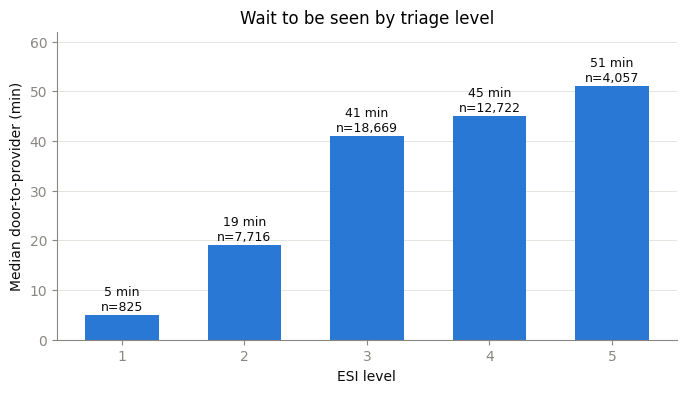

In [3]:
by_esi = seen.groupby("esi_level")["door_to_provider_min"].agg(["median", "size"])
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(by_esi.index.astype(str), by_esi["median"], color=BLUE, width=0.6)
for i, (m, n) in enumerate(zip(by_esi["median"], by_esi["size"])):
    ax.text(i, m + 1, f"{m:.0f} min\nn={n:,}", ha="center", fontsize=9, color=INK)
ax.set_xlabel("ESI level"); ax.set_ylabel("Median door-to-provider (min)"); ax.set_title("Wait to be seen by triage level")
ax.set_ylim(0, 62); ax.grid(axis="x", visible=False)
plt.show()

The steps between levels are far from equal: from ESI 1 to 2 the median wait quadruples, from 4 to 5 it grows by a few minutes. That is why ESI cannot be dropped into the model as a number, which would force the same step between every pair of neighbouring levels. Each level needs its **own** effect.

## 3. How a category enters an equation

A linear model can only multiply numbers by coefficients. To give five categories five effects, we create **dummy columns**: one 0/1 column per level, equal to 1 when the visit is at that level and 0 otherwise.

In [4]:
seen["esi_label"] = "ESI " + seen["esi_level"].astype(str)
dummies = pd.get_dummies(seen["esi_label"]).astype(int)
pd.concat([seen[["visit_id", "esi_label"]], dummies], axis=1).head(8)

,visit_id,esi_label,ESI 1,ESI 2,ESI 3,ESI 4,ESI 5
0,E000001,ESI 3,0,0,1,0,0
1,E000002,ESI 3,0,0,1,0,0
2,E000003,ESI 4,0,0,0,1,0
4,E000005,ESI 1,1,0,0,0,0
5,E000006,ESI 3,0,0,1,0,0
6,E000007,ESI 3,0,0,1,0,0
7,E000008,ESI 3,0,0,1,0,0
8,E000009,ESI 4,0,0,0,1,0


Every row has exactly one 1 across the five columns. But we cannot use all five in the model, because they always add up to 1: if a visit is not ESI 1, 2, 4 or 5, it *must* be ESI 3, so the fifth column carries no new information and the model cannot separate it from the intercept. One level is therefore **left out**. It becomes the **reference level**, and each remaining dummy gets a coefficient that means:

> *the difference in expected log wait between this level and the reference level, for a patient with the same census, hour and labs.*

Which level to leave out is our choice, and it matters for how the numbers read, not for what the model predicts. We choose **ESI 3**, the most common level and the clinical middle, so that every coefficient reads "compared with a typical urgent patient".

Written out, the model is:

$$\log(\text{wait}) = \beta_0 + \beta_1\,\text{census} + \beta_2\,\text{hour} + \beta_3\,\text{hour}^2 + \beta_4\,\text{labs} \;+\; \beta_{\text{ESI1}}\,[\text{ESI}=1] + \beta_{\text{ESI2}}\,[\text{ESI}=2] + \beta_{\text{ESI4}}\,[\text{ESI}=4] + \beta_{\text{ESI5}}\,[\text{ESI}=5]$$

where $[\text{ESI}=k]$ is the dummy: 1 for a patient at level $k$, 0 otherwise. For an ESI 3 patient all four dummies are 0 and the equation is the original one. For an ESI 2 patient, exactly one dummy is 1 and the equation is the original one **plus $\beta_{\text{ESI2}}$**. A dummy coefficient is a shift of the intercept for that group; the slopes on census, hour and labs are shared by everyone.

## 4. Fitting the model

statsmodels builds the dummy columns from the formula: `C(esi_label, Treatment("ESI 3"))` says "treat as categorical, reference ESI 3".

In [5]:
model_4 = smf.ols(base + " + C(esi_label, Treatment('ESI 3'))", data=seen).fit()
print(f"Model 3 (no ESI):  R² = {model_3.rsquared:.3f}")
print(f"Model 4 (with ESI): R² = {model_4.rsquared:.3f}")
print()
print(model_4.summary().tables[1])

Model 3 (no ESI):  R² = 0.222
Model 4 (with ESI): R² = 0.470

                                                coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------
Intercept                                     3.1561      0.011    280.414      0.000       3.134       3.178
C(esi_label, Treatment('ESI 3'))[T.ESI 1]    -2.1622      0.019   -112.748      0.000      -2.200      -2.125
C(esi_label, Treatment('ESI 3'))[T.ESI 2]    -0.7484      0.007   -101.069      0.000      -0.763      -0.734
C(esi_label, Treatment('ESI 3'))[T.ESI 4]     0.0921      0.006     14.197      0.000       0.079       0.105
C(esi_label, Treatment('ESI 3'))[T.ESI 5]     0.2042      0.010     21.196      0.000       0.185       0.223
ed_census_at_arrival                          0.0205      0.000     74.212      0.000       0.020       0.021
arrival_hour                                 -0.0021      

R² has more than doubled, from 0.22 to 0.47: acuity is the largest single influence on how quickly someone is seen. The four ESI rows are the coefficients we set out to understand. Each has an estimate, a standard error and a confidence interval, exactly like the continuous predictors, but their meaning is different and is best seen in pictures.

(One side effect worth a glance: the `n_labs` coefficient, which was −0.12 in model 3, is now essentially zero. Labs never sped anyone up; sicker patients get more tests *and* are seen faster, and until ESI was in the model, labs were standing in for acuity. Adding the right variable removed the illusion.)

## 5. Reading the betas, in three pictures

### Picture 1: five parallel lines

Fix hour and labs at typical values and draw the model's expected log wait against census, one line per ESI level. Because the dummies shift only the intercept, the five lines are **parallel**: the same slope for census, different heights. The vertical gap between any line and the ESI 3 line is that level's beta.

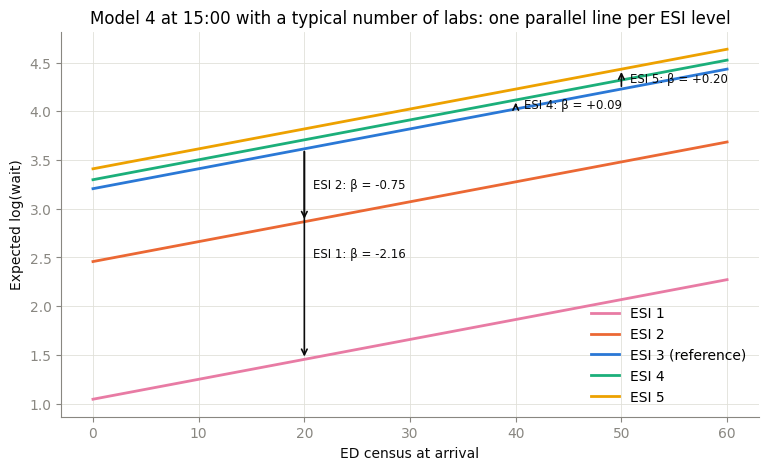

In [6]:
esi_colors = {"ESI 1": MAGENTA, "ESI 2": ORANGE, "ESI 3": BLUE, "ESI 4": AQUA, "ESI 5": YELLOW}
census_grid = np.arange(0, 61)
typical = {"arrival_hour": 15, "n_labs": int(seen["n_labs"].median())}

fig, ax = plt.subplots(figsize=(9, 5))
for lvl, colr in esi_colors.items():
    grid = pd.DataFrame({"ed_census_at_arrival": census_grid, "esi_label": lvl, **typical})
    ax.plot(census_grid, model_4.predict(grid), color=colr, linewidth=2, label=lvl + (" (reference)" if lvl == "ESI 3" else ""))
# mark each beta as a vertical gap from the reference line (at different census values so the labels do not collide)
arrow_x = {"ESI 1": 20, "ESI 2": 20, "ESI 4": 40, "ESI 5": 50}
for lvl, x in arrow_x.items():
    ref = model_4.predict(pd.DataFrame({"ed_census_at_arrival": [x], "esi_label": "ESI 3", **typical})).iloc[0]
    b = model_4.params[f"C(esi_label, Treatment('ESI 3'))[T.{lvl}]"]
    ax.annotate("", xy=(x, ref + b), xytext=(x, ref), arrowprops=dict(arrowstyle="->", color=INK, lw=1.2))
    ax.text(x + 0.8, ref + b / 2, f"{lvl}: β = {b:+.2f}", fontsize=8.5, color=INK, va="center")
ax.set_xlabel("ED census at arrival"); ax.set_ylabel("Expected log(wait)")
ax.set_title("Model 4 at 15:00 with a typical number of labs: one parallel line per ESI level")
ax.legend(frameon=False, loc="lower right"); plt.show()

Read the arrows. The ESI 2 line sits 0.75 below the reference line and the ESI 1 line more than 2 below; ESI 4 and 5 sit a little above it. Those vertical distances **are** the betas, and they would be the same wherever along the census axis we drew them, because the lines are parallel. That is the whole content of a dummy coefficient: *how far this group's line sits above or below the reference group's line.*

### Picture 2: the betas with their uncertainty

A coefficient plot shows each beta as a point with its 95% confidence interval, and the reference level as zero by definition.

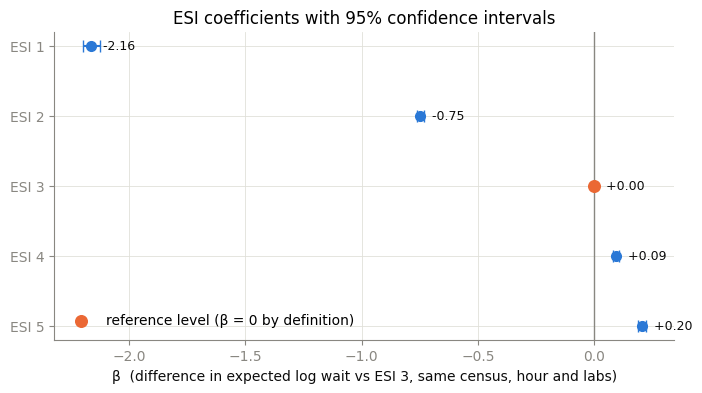

In [7]:
labels = ["ESI 1", "ESI 2", "ESI 3", "ESI 4", "ESI 5"]
betas, lo, hi = [], [], []
ci = model_4.conf_int()
for lvl in labels:
    if lvl == "ESI 3":
        betas.append(0); lo.append(0); hi.append(0)
    else:
        name = f"C(esi_label, Treatment('ESI 3'))[T.{lvl}]"
        betas.append(model_4.params[name]); lo.append(ci.loc[name, 0]); hi.append(ci.loc[name, 1])

fig, ax = plt.subplots(figsize=(8, 4))
ax.axvline(0, color=MUTED, linewidth=1)
ax.errorbar(betas, labels, xerr=[np.array(betas) - np.array(lo), np.array(hi) - np.array(betas)], fmt="o", color=BLUE, ecolor=BLUE, capsize=4, markersize=7)
ax.scatter([0], ["ESI 3"], color=ORANGE, s=70, zorder=3, label="reference level (β = 0 by definition)")
for b, l in zip(betas, labels):
    ax.text(b, l, f"   {b:+.2f}", va="center", fontsize=9, color=INK)
ax.set_xlabel("β  (difference in expected log wait vs ESI 3, same census, hour and labs)")
ax.set_title("ESI coefficients with 95% confidence intervals"); ax.invert_yaxis(); ax.legend(frameon=False, loc="lower left")
plt.show()

The intervals are narrow (there are thousands of visits at every level), and none of the four crosses zero: every level differs from ESI 3 by more than chance would produce. Notice the *unequal spacing* down the plot, which is the reason we used dummies rather than a single slope: 1 → 2 is a large step, 4 → 5 a small one.

### Picture 3: from betas to minutes

Betas on the log scale are hard to feel. Convert them: $e^{\beta}$ is the **ratio** of expected waits between that level and the reference. And for a concrete patient (15:00, 30 patients in the department, a typical number of labs) the model gives a predicted wait in minutes at each level.

In [8]:
patient = pd.DataFrame({"ed_census_at_arrival": 30, "arrival_hour": 15, "n_labs": int(seen["n_labs"].median()), "esi_label": labels})
patient["predicted_wait_min"] = np.exp(model_4.predict(patient))
patient["ratio_vs_ESI3"] = [np.exp(b) for b in betas]
patient["beta"] = betas
patient[["esi_label", "beta", "ratio_vs_ESI3", "predicted_wait_min"]].round(2)

,esi_label,beta,ratio_vs_ESI3,predicted_wait_min
0,ESI 1,-2.16,0.12,5.25
1,ESI 2,-0.75,0.47,21.58
2,ESI 3,0.00,1.00,45.61
3,ESI 4,0.09,1.10,50.01
4,ESI 5,0.20,1.23,55.94


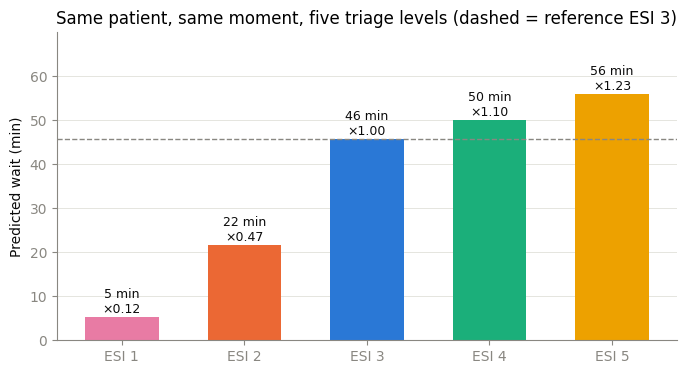

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(labels, patient["predicted_wait_min"], color=[esi_colors[l] for l in labels], width=0.6)
ref_wait = patient.loc[patient["esi_label"] == "ESI 3", "predicted_wait_min"].iloc[0]
ax.axhline(ref_wait, color=MUTED, linestyle="--", linewidth=1)
for l, w, r in zip(labels, patient["predicted_wait_min"], patient["ratio_vs_ESI3"]):
    ax.text(l, w + 1, f"{w:.0f} min\n×{r:.2f}", ha="center", fontsize=9, color=INK)
ax.set_ylabel("Predicted wait (min)"); ax.set_title("Same patient, same moment, five triage levels (dashed = reference ESI 3)")
ax.set_ylim(0, patient["predicted_wait_min"].max() * 1.25); ax.grid(axis="x", visible=False)
plt.show()

This is the sentence a clinician needs: *for the same crowding, the same time of day and the same work-up, an ESI 2 patient is seen in about half the time of an ESI 3 patient, an ESI 1 patient in about a tenth, and ESI 4 and 5 patients wait 10–20% longer.* The three pictures say the same thing three ways: a shift between parallel lines, a point on a coefficient plot, a ratio of minutes.

## 6. Changing the reference level

Suppose we had left out ESI 1 instead of ESI 3. Every ESI coefficient changes, because each is now a difference *from ESI 1*. What does not change is the model itself: R² and every prediction are identical.

In [10]:
model_4b = smf.ols(base + " + C(esi_label, Treatment('ESI 1'))", data=seen).fit()
rows = {}
for lvl in labels:
    a = 0.0 if lvl == "ESI 3" else model_4.params[f"C(esi_label, Treatment('ESI 3'))[T.{lvl}]"]
    b = 0.0 if lvl == "ESI 1" else model_4b.params[f"C(esi_label, Treatment('ESI 1'))[T.{lvl}]"]
    rows[lvl] = {"β with reference ESI 3": a, "β with reference ESI 1": b}
compare = pd.DataFrame(rows).T.round(3)
compare["difference between the two"] = (compare.iloc[:, 1] - compare.iloc[:, 0]).round(3)
print(f"R²:  reference ESI 3 → {model_4.rsquared:.4f}   reference ESI 1 → {model_4b.rsquared:.4f}")
print("Predictions identical on every visit:", bool(np.allclose(model_4.fittedvalues, model_4b.fittedvalues)))
compare

R²:  reference ESI 3 → 0.4703   reference ESI 1 → 0.4703
Predictions identical on every visit: True


,β with reference ESI 3,β with reference ESI 1,difference between the two
ESI 1,-2.162,0.000,2.162
ESI 2,-0.748,1.414,2.162
ESI 3,0.000,2.162,2.162
ESI 4,0.092,2.254,2.162
ESI 5,0.204,2.366,2.162


Every beta moved by the same amount (the distance between the two reference levels), and the predictions did not move at all. The betas are **relative** quantities; the reference is the zero of the ruler. Choose the reference for readability, state it, and never compare betas across models that used different ones.

## 7. Summary

| | Continuous predictor | Qualitative predictor (dummies) |
|---|---|---|
| Columns in the model | one | one per level, minus the reference |
| β means | change in expected log wait per unit | difference in expected log wait between this level and the reference, other predictors fixed |
| Picture | a slope | a set of parallel lines at different heights |
| In clinical units | $e^{\beta}$ per unit | $e^{\beta}$ = ratio of expected waits vs the reference |
| Zero | no effect | same as the reference level |

Adding one qualitative variable took the model from explaining 22% of the variation to 47%, made a spurious effect disappear, and produced four numbers that translate directly into how much sooner or later each triage level is seen. The next step, in later sessions, is to add more qualitative variables the same way, one at a time, watching what each does to the ones already there.